In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import update_rate_by_strict_pairs,plot_time_series_ranging

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)
pd.set_option('display.max_rows', None)
ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)

RESAMPLE_RULE = "1S"

static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}

TEST_FILE_NAME = "2021-05-25-11-13-08-moving-v2-4-west-12mph"

In [2]:
test_file_list, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, "Moving Test 1 (V2V)", "V2", CALIBRATED_CAM_TO_V2B)
assert(len(test_file_list) == len(ground_truth_list))
for i in range(len(test_file_list)):
    test_file, ground_truth = test_file_list[i], ground_truth_list[i]
    if "data-A-user-processed_log" in test_file and os.path.basename(test_file).startswith("2021"):
        continue
    if TEST_FILE_NAME in test_file:
        _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
        _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
        _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
        fdir = _integ_csv_dir
        df = pd.read_csv(fdir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
        break

plotting: 2021-05-25-11-13-08-moving-v2-4-west-12mph


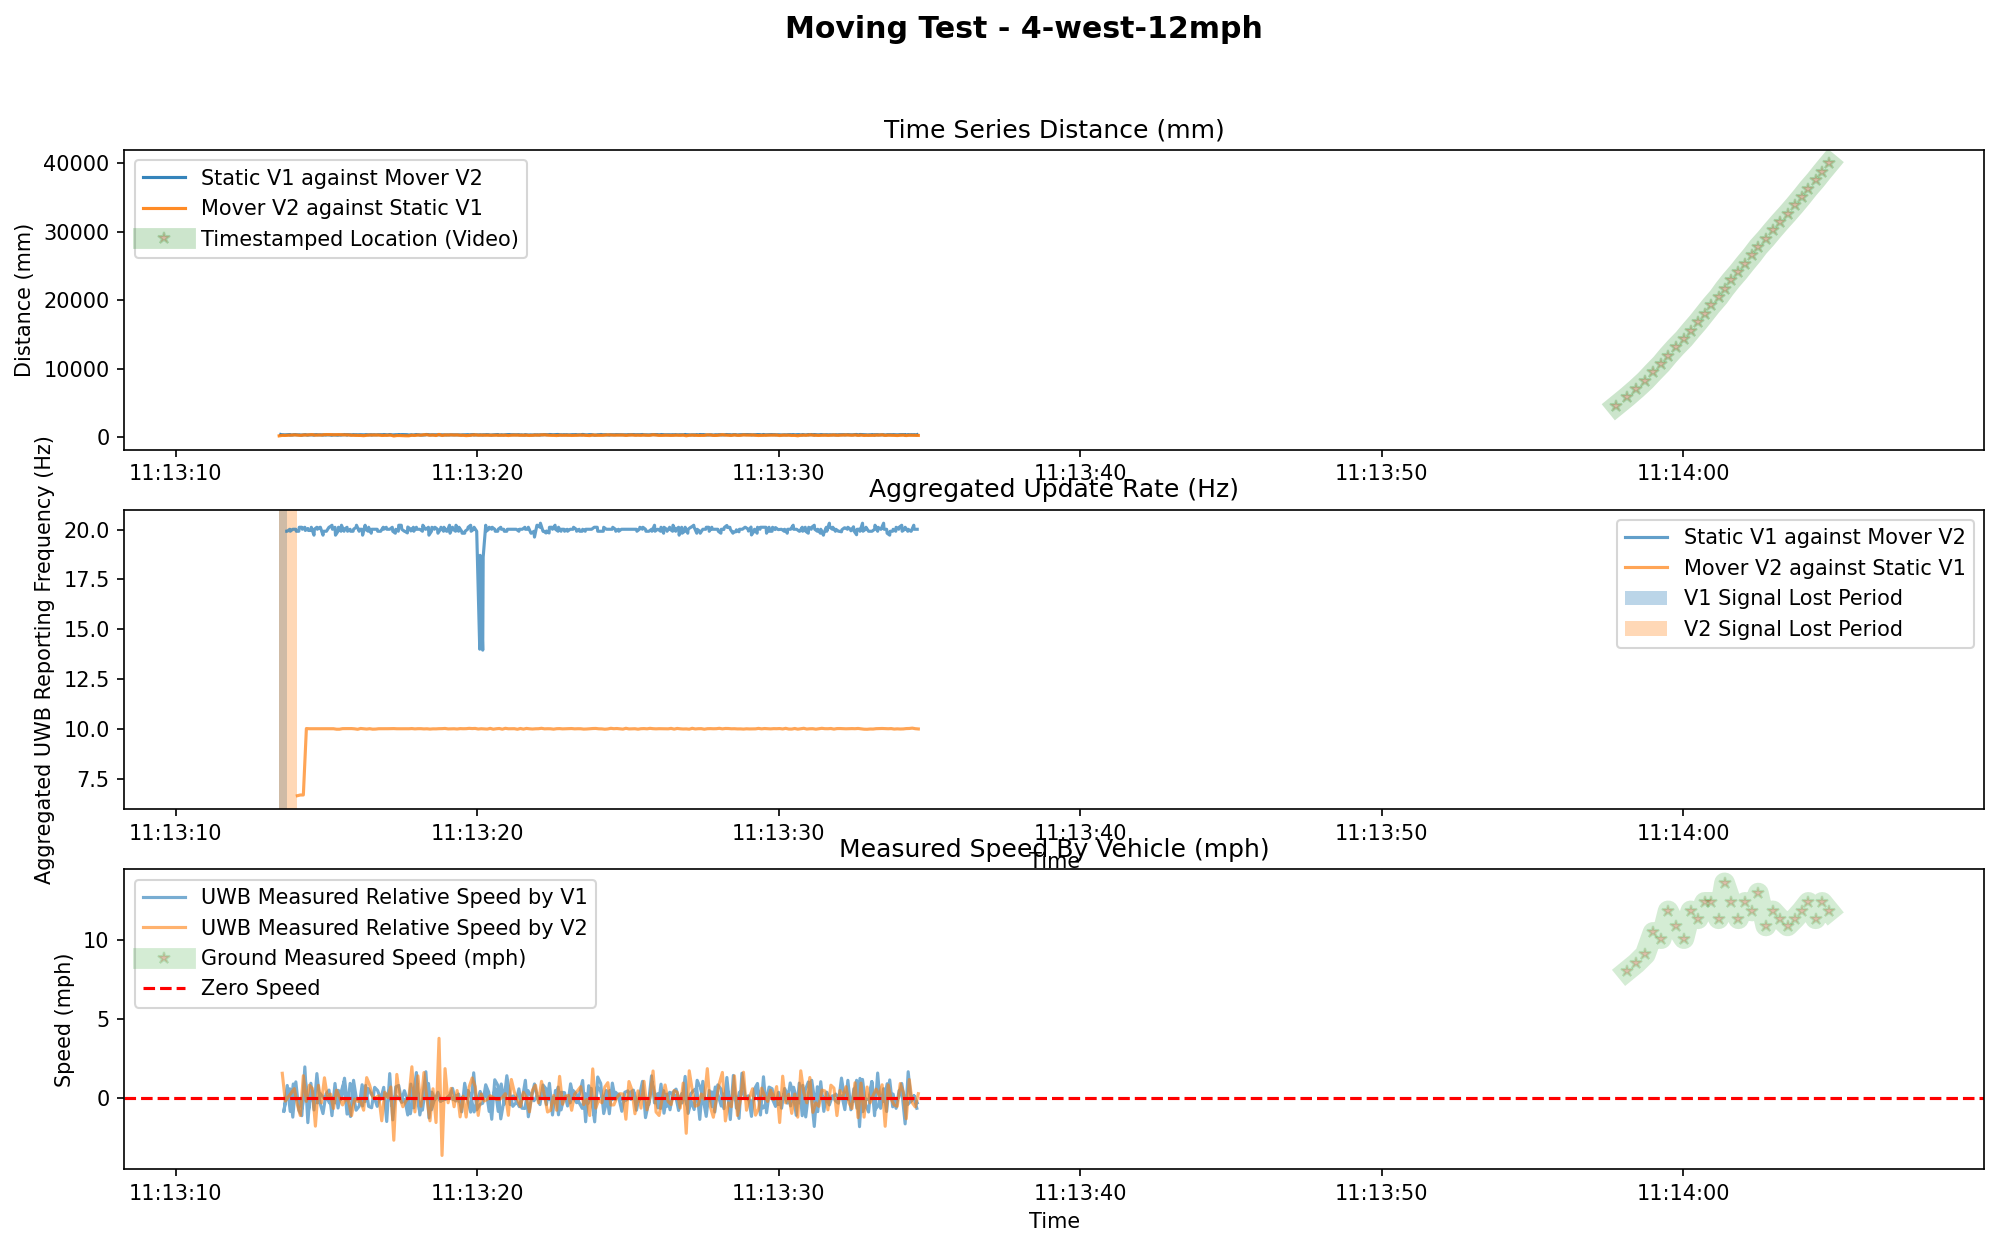

[Timestamp('2021-05-25 11:13:13.428440064'), Timestamp('2021-05-25 11:14:04.846338048')]


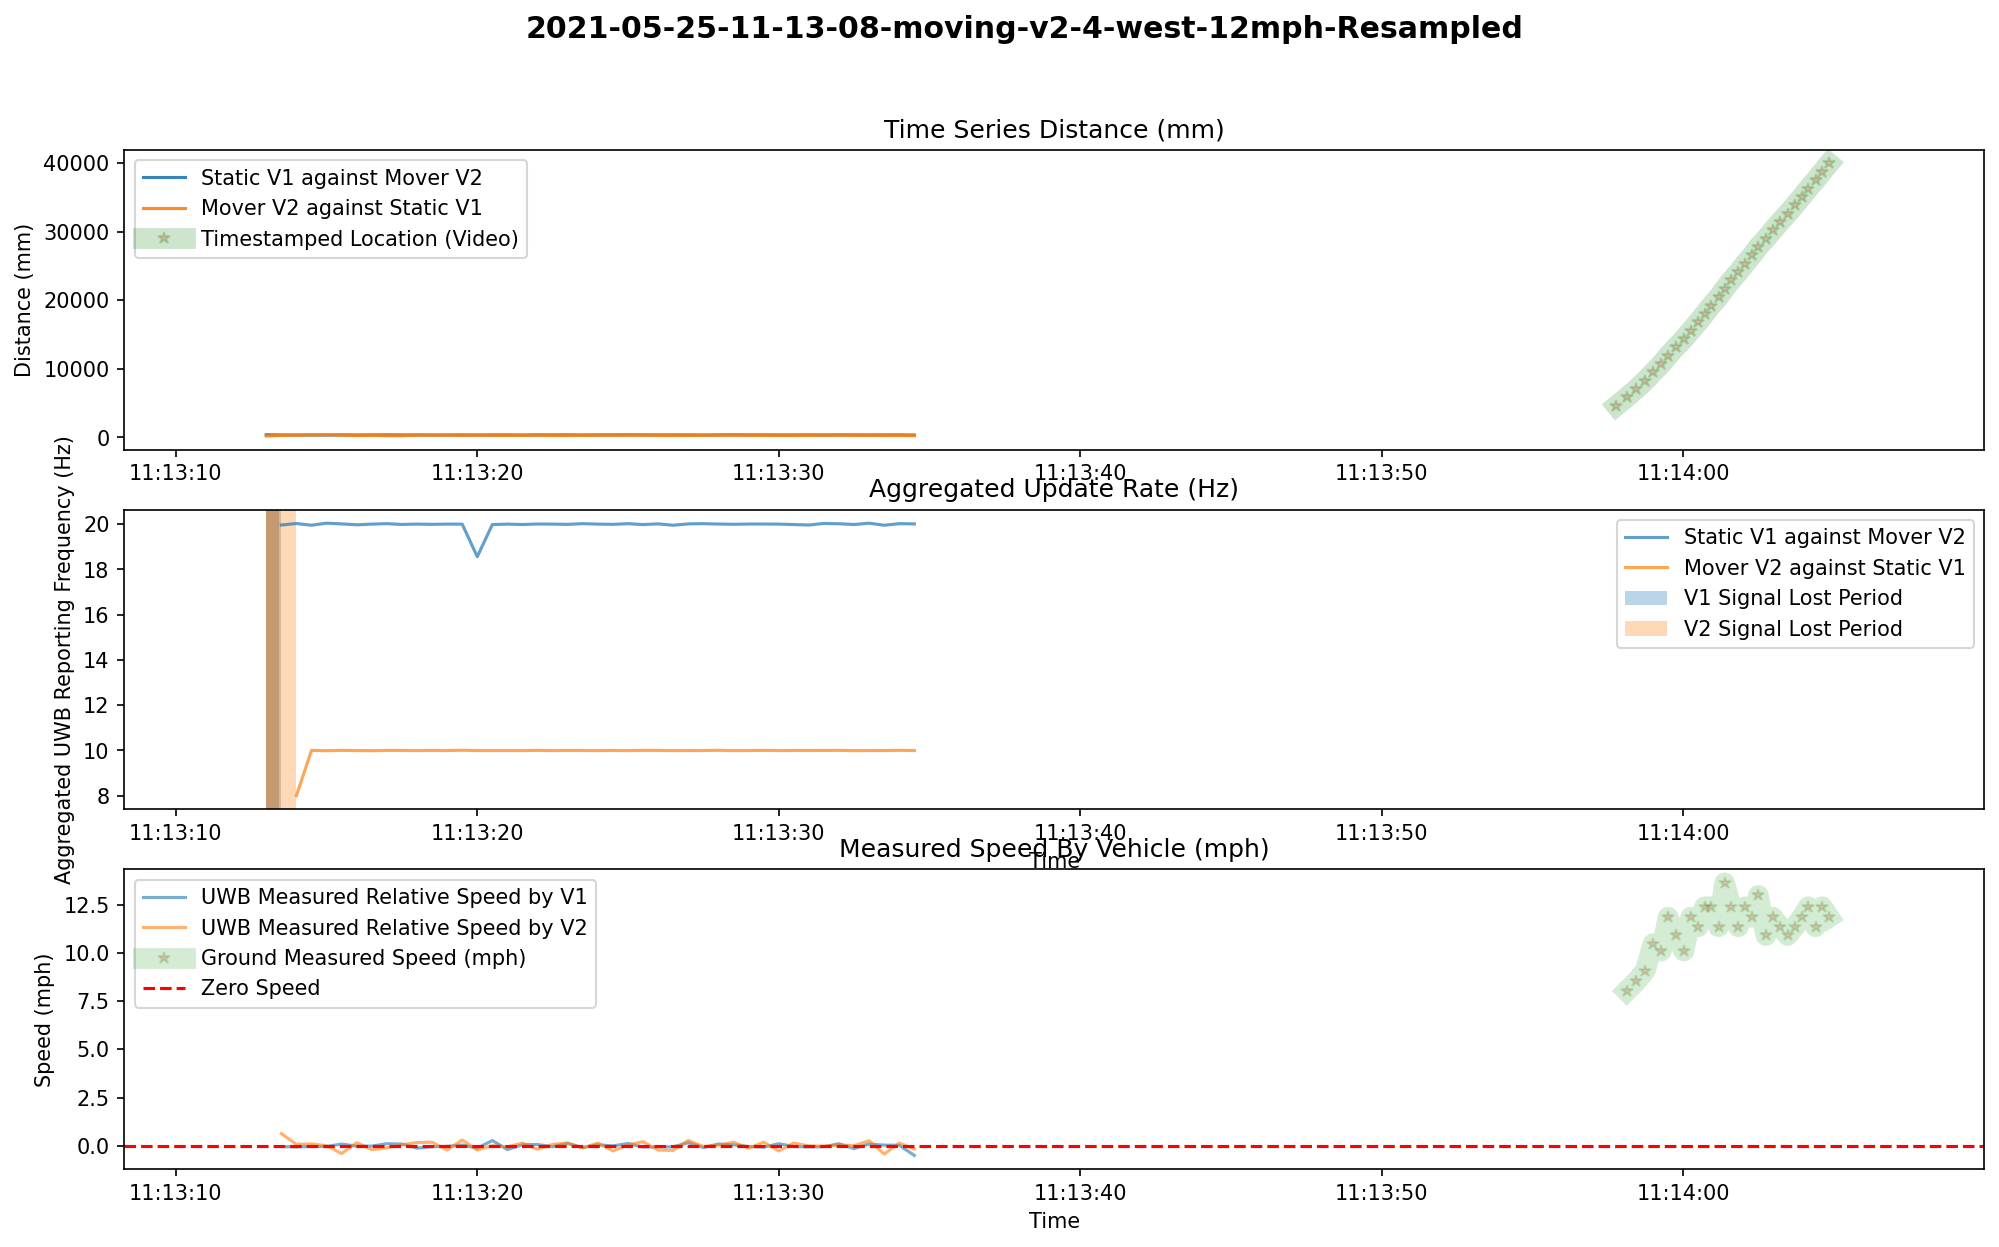

In [3]:
plot_time_series_ranging(_integ_csv_dir, ground_truth, static_veh=1, is_static_plot=False, moving_veh=2, resample_rule=RESAMPLE_RULE)

#### df_static_veh_hz_cleaned_all_pairs_outlier_removed_resampled['Aggregated Update Rate (Hz)']

In [4]:
static_veh = 1
moving_veh = 2
df_static_veh_all_pairs = df[df['Initiating Vehicle'] == static_veh]
df_moving_veh_all_pairs = df[df['Initiating Vehicle'] == moving_veh]
df_static_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs( df_static_veh_all_pairs, 
                                                                                static_master_slave_mapping.keys(), 
                                                                                static_focusing_slaves)
df_moving_veh_hz_aggregated_all_pairs = update_rate_by_strict_pairs( df_moving_veh_all_pairs, 
                                                                            moving_master_slave_mapping.keys(), 
                                                                            moving_focusing_slaves)
moving_ground_truth_df = ground_truth
if moving_ground_truth_df is None:
    time_stamp_lim = [df.index.min(),df.index.max()]
else:
    min_time = min(df.index.min(), pd.to_datetime(moving_ground_truth_df["Time UNIX Norm (s)"],unit='s').min())
    max_time = max(df.index.max(), pd.to_datetime(moving_ground_truth_df["Time UNIX Norm (s)"],unit='s').max())
    time_range = max_time - min_time
    time_stamp_lim = [min_time,max_time]

In [5]:
_raw_data_static_whole = df[df['Initiating Vehicle'] == static_veh]
_raw_data_moving_whole = df[df['Initiating Vehicle'] == moving_veh]
_raw_data_static = _raw_data_static_whole["Correction Distance (mm)"]
_raw_data_moving = _raw_data_moving_whole["Correction Distance (mm)"]
static_hist_disp_range = (_raw_data_static.quantile(0.05), _raw_data_static.quantile(0.95))
static_hist_disp_range = None if np.nan in static_hist_disp_range else static_hist_disp_range
binwidth = 20
static_bins = np.arange(min(_raw_data_static), max(_raw_data_static) + binwidth, binwidth) if not _raw_data_static.empty else None
moving_hist_disp_range = (_raw_data_moving.quantile(0.05), _raw_data_moving.quantile(0.95))
moving_hist_disp_range = None if np.nan in moving_hist_disp_range else moving_hist_disp_range
moving_bins = np.arange(min(_raw_data_moving), max(_raw_data_moving) + binwidth, binwidth) if not _raw_data_moving.empty else None

In [6]:
def get_nan_slices_indices(df, veh, time_stamp_lim):
    slices = []
    _flag = False
    
    for i in range(len(df['Aggregated Update Rate (Hz)'])):
        if not np.isnan(df.iloc[i]['Aggregated Update Rate (Hz)']):
            if _flag == True:
                if slices:
                    slices[-1].append(df.iloc[i]["Datetime Normalized"])
                    _flag = not _flag
        else:
            if _flag == False:
                if 0 < i-1 < len(df['Aggregated Update Rate (Hz)']) - 1:
                    slices.append([df.iloc[i-1]["Datetime Normalized"]])
                    _flag = not _flag
                if 0 == i:
                    slices.append([df.iloc[i]["Datetime Normalized"]])
                    _flag = not _flag
                if len(df['Aggregated Update Rate (Hz)']) - 1 == i:
                    if slices:
                        slices[-1].append(df.iloc[i]["Datetime Normalized"])
    if slices:
        _nan_start, _nan_stop = slices[0][0], slices[-1][-1]
        if df[(df["Datetime Normalized"] < _nan_start) & (df["Datetime Normalized"] > df[df['Initiating Vehicle']==veh]["Datetime Normalized"].min())]['Aggregated Update Rate (Hz)'].size <= 1:
            slices.insert(0, [time_stamp_lim[0], _nan_start])
        if df[(df["Datetime Normalized"] > _nan_stop) & (df["Datetime Normalized"] < df[df['Initiating Vehicle']==veh]["Datetime Normalized"].max())]['Aggregated Update Rate (Hz)'].size <= 1:
            slices.append([_nan_stop, time_stamp_lim[1]])
    else:
        _nan_start, _nan_stop = df["Datetime Normalized"].min(), df["Datetime Normalized"].max()
        slices.insert(0, [min(time_stamp_lim[0], _nan_start), max(time_stamp_lim[0], _nan_start)])
        slices.append([min(time_stamp_lim[1], _nan_stop), max(time_stamp_lim[1], _nan_stop)])
    import itertools
    slices.sort()
    return list(k for k,_ in itertools.groupby(slices))

def plot_upd_rate(figure, arrange_spec, static_veh_df, moving_veh_df, static_veh, moving_veh, time_stamp_lim, resample=False):
    ax = figure.add_subplot(arrange_spec)
    if resample:
        static_veh_df = static_veh_df.resample(rule=RESAMPLE_RULE).mean()
        moving_veh_df = moving_veh_df.resample(rule=RESAMPLE_RULE).mean()
    ax.plot( static_veh_df.index, 
             static_veh_df["Aggregated Update Rate (Hz)"], 
             label="Static V{} against Mover V{}".format(static_veh, moving_veh),
             alpha=0.7,
             color='C0')
    ax.plot( moving_veh_df.index, 
             moving_veh_df["Aggregated Update Rate (Hz)"], 
             label="Mover V{} against Static V{}".format(moving_veh, static_veh),
             alpha=0.7,
             color='C1')
    # ax.axhline(y=MAX_UPD_RATE, color='r', linestyle='dashed', label="Max Update Rate (All Devices Connected)", alpha=0.9)
    # ax.axhline(y=NUL_UPD_RATE, color='r', linestyle='dashed', label="Min Update Rate (No Devices Connected)", alpha=0.9)
    ax.set_title("Aggregated Update Rate (Hz)")
    ax.set_xlabel("Time")
    _time_span = time_stamp_lim[1] - time_stamp_lim[0]
    _xlim = [time_stamp_lim[0] - 0.1 * _time_span, time_stamp_lim[1] + 0.1 * _time_span]
    ax.set_xlim(_xlim)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_ylabel("Aggregated UWB Reporting Frequency (Hz)")

    # Span for missing values
    reindexed_static = static_veh_df.reset_index()
    reindexed_moving = moving_veh_df.reset_index()
    static_nan_slices = get_nan_slices_indices(reindexed_static, veh=static_veh, time_stamp_lim=time_stamp_lim)
    moving_nan_slices = get_nan_slices_indices(reindexed_moving, veh=moving_veh, time_stamp_lim=time_stamp_lim)
    for i in range(len(static_nan_slices)):
        slice = static_nan_slices[i]
        if len(slice) < 2:
            continue
        [slice_lo, slice_hi] = slice
        ax.axvspan( slice_lo, slice_hi,
                    facecolor='C0',
                    alpha=0.3,
                    label="_" * i + "V{} Signal Lost Period".format(static_veh))

    for i in range(len(moving_nan_slices)):
        slice = moving_nan_slices[i]
        if len(slice) < 2:
            continue
        [slice_lo, slice_hi] = slice
        ax.axvspan( slice_lo, slice_hi,
                    facecolor='C1',
                    alpha=0.3,
                    label="_" * i + "V{} Signal Lost Period".format(moving_veh))
    ax.legend()

In [7]:
figure_resample = plt.figure(figsize=(16, 9), dpi=150)
titlename = os.path.basename(os.path.dirname(fdir)) + "-Resampled"
figure_resample.suptitle(titlename, fontsize='x-large', fontweight='bold')

Text(0.5, 0.98, '2021-05-25-11-13-08-moving-v2-4-west-12mph-Resampled')

<Figure size 2400x1350 with 0 Axes>

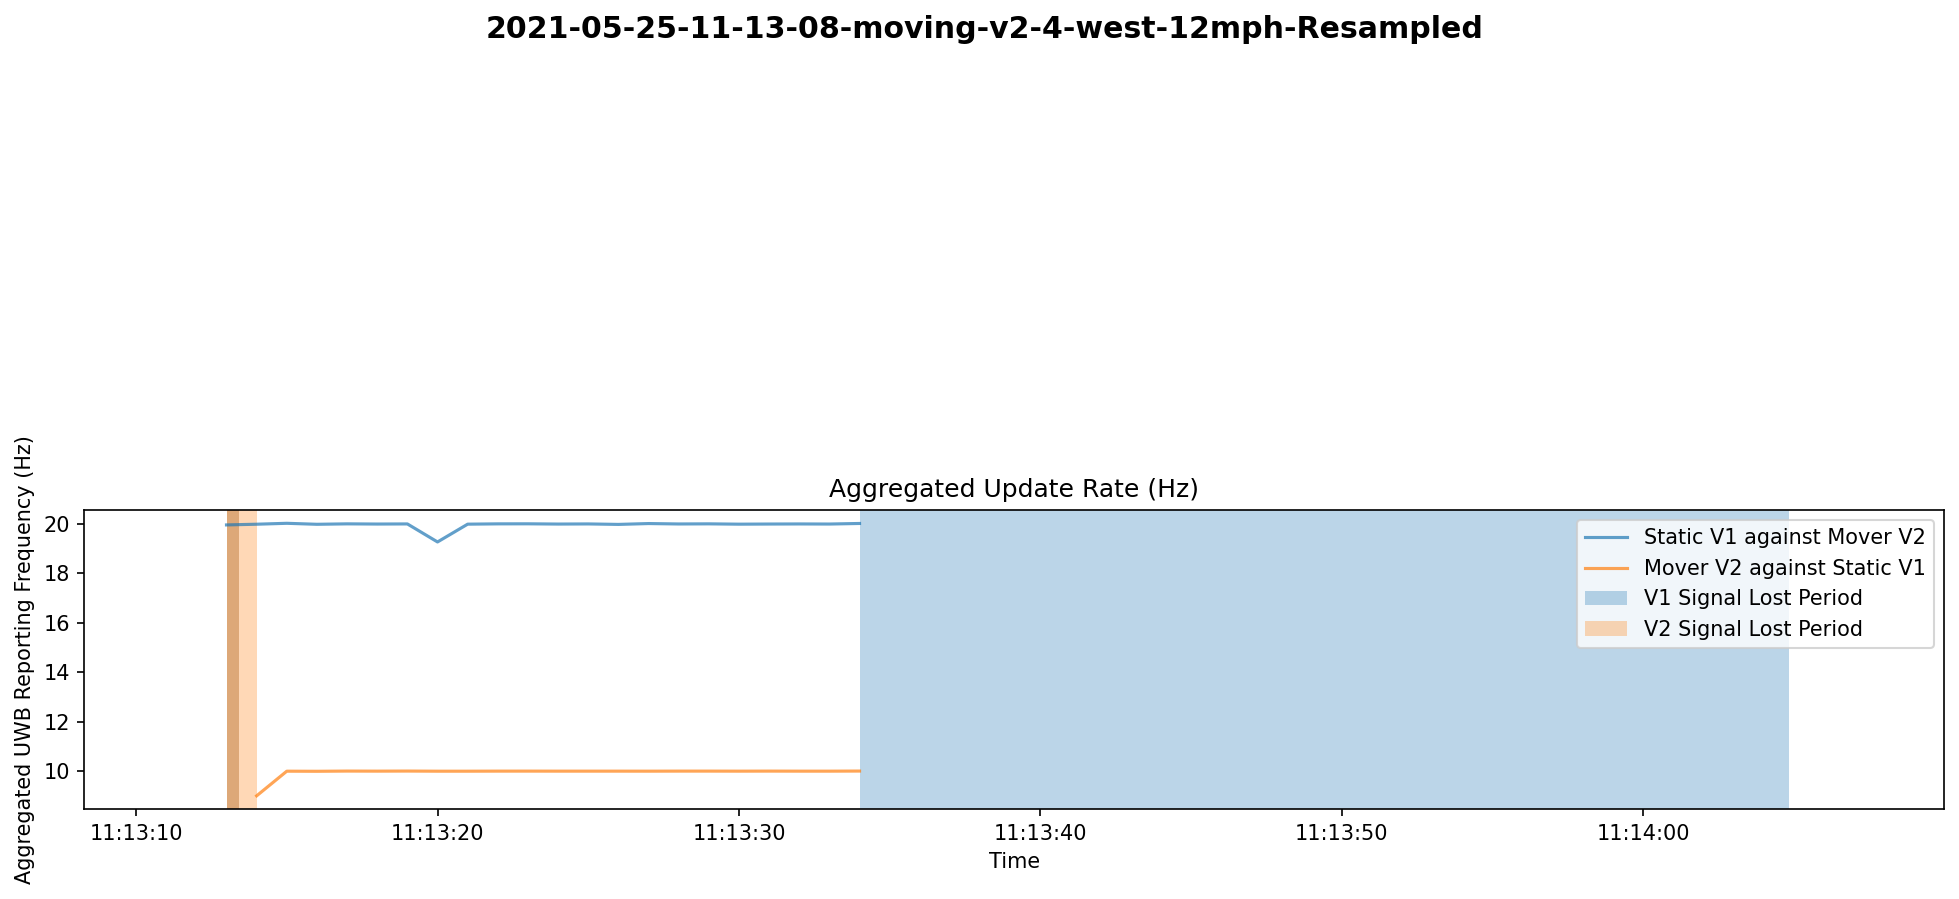

In [8]:
figure_resample = plt.figure(figsize=(16, 9), dpi=150)
titlename = os.path.basename(os.path.dirname(fdir)) + "-Resampled"
figure_resample.suptitle(titlename, fontsize='x-large', fontweight='bold')
RESAMPLE_RULE_1S = "1S"
static_veh = 1
moving_veh = 2
_test_df = None
plot_upd_rate(  figure=figure_resample,
                arrange_spec=312,
                static_veh_df=df_static_veh_hz_aggregated_all_pairs,
                moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                static_veh=static_veh,
                moving_veh=moving_veh,
                time_stamp_lim=time_stamp_lim,
                resample=True)
        
plt.show()

In [9]:
time_stamp_lim

[Timestamp('2021-05-25 11:13:13.428440064'),
 Timestamp('2021-05-25 11:14:04.846338048')]